# Vergleich: ästhetische Qualität


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, spearmanr


In [2]:
DATA_DIR = Path('../../data')
INPUT_CSV = DATA_DIR / '04_analysis_results' / 'visual_features' / '08_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_aesthetic_quality.csv'
print(f'Reading {INPUT_CSV}')
df = pd.read_csv(INPUT_CSV)

print(df[['influencer_type', 'aesthetic_quality_score', 'aesthetic_quality_scored_frames']].groupby('influencer_type').agg(['count', 'mean', 'std']))


Reading ../../data/04_analysis_results/visual_features/08_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_aesthetic_quality.csv                aesthetic_quality_score                      \                                  count      mean       std   influencer_type                                               ai                                  250  4.683875  0.874523   real                                250  4.363386  0.651804                   aesthetic_quality_scored_frames                                                               count    mean        std  influencer_type                                                     ai                                          250  18.564  17.329256  real                                        250  43.156  49.010568  

In [3]:
FRAME_ROOT = DATA_DIR / '02_media/stratified_sample/frames'

def get_video_id(row):
    return str(row.get('id') or row.get('video_id'))

def first_frame_path(video_id: str):
    folder = FRAME_ROOT / video_id
    if not folder.is_dir():
        return None
    frames = sorted(folder.glob('*.jpeg'))
    if not frames:
        frames = sorted(folder.glob('*.jpg'))
    if not frames:
        return None
    return frames[len(frames) // 2]

def load_image(path):
    import cv2
    img = cv2.imread(str(path))
    if img is None:
        return None
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


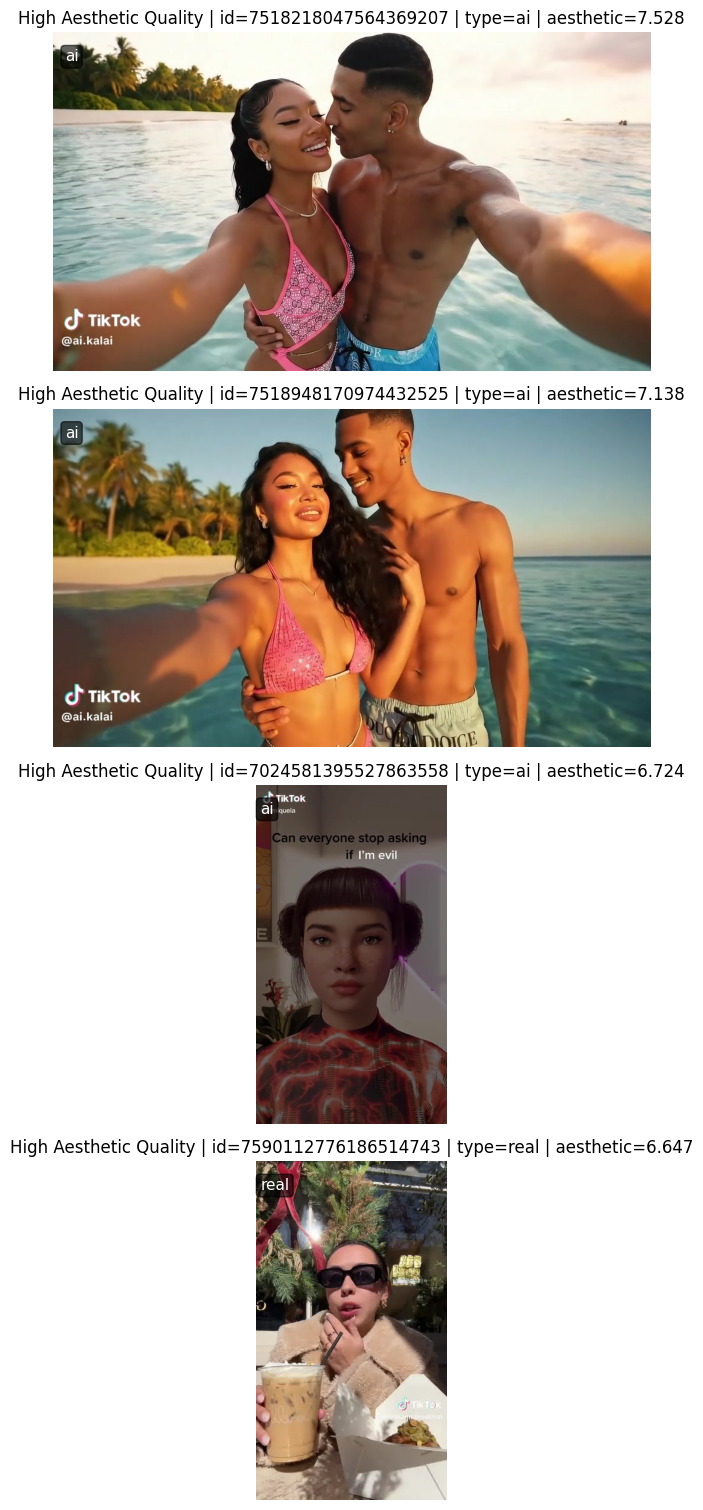

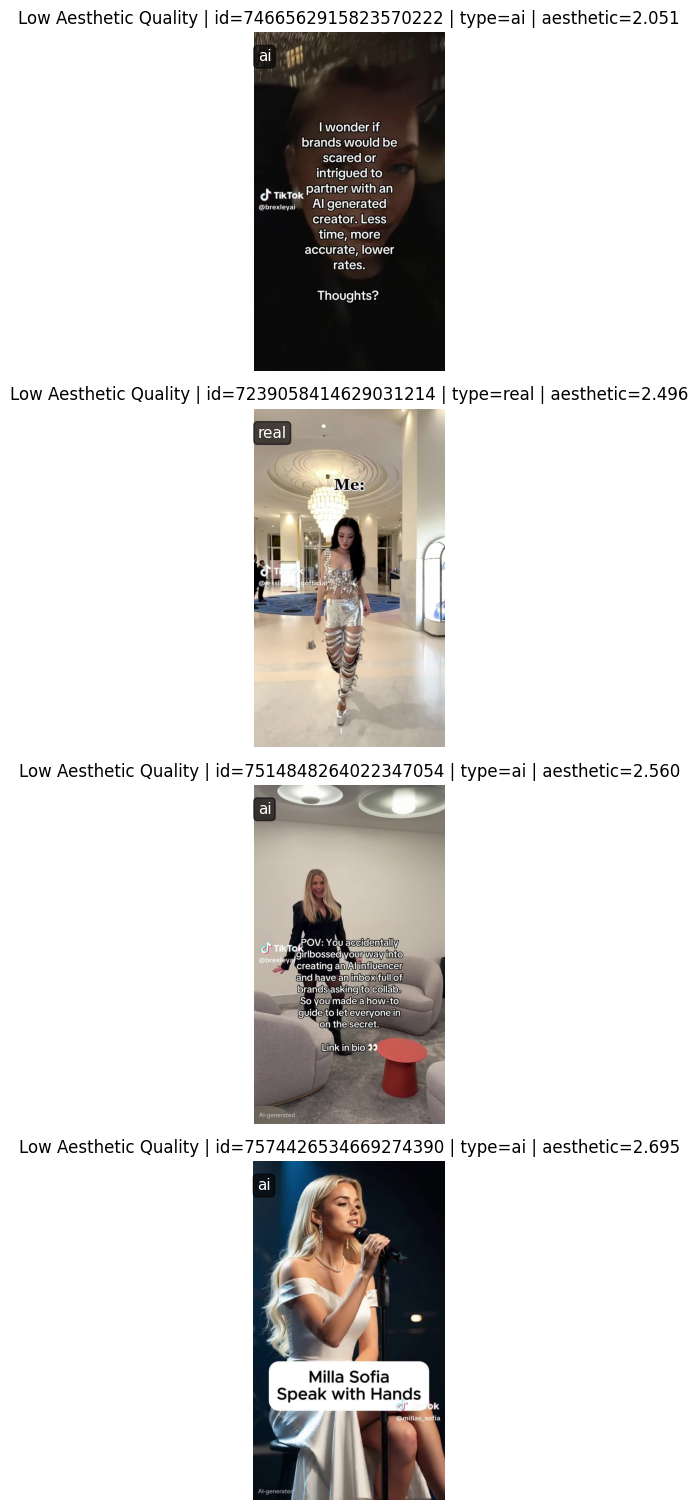

In [4]:
_df = df.dropna(subset=['aesthetic_quality_score']).copy()

def pick_examples(df_sorted, n=4):
    rows = []
    for _, row in df_sorted.iterrows():
        vid = get_video_id(row)
        fp = first_frame_path(vid)
        if fp is None:
            continue
        row = row.copy()
        row['frame_path'] = fp
        rows.append(row)
        if len(rows) >= n:
            break
    return rows

def show_examples(rows, title):
    if not rows:
        print(f'No frames found for {title}')
        return
    plt.figure(figsize=(12, 3.8 * len(rows)))
    for i, row in enumerate(rows, 1):
        img = load_image(row['frame_path'])
        ax = plt.subplot(len(rows), 1, i)
        if img is not None:
            ax.imshow(img)
            ax.axis('off')
        else:
            ax.text(0.5, 0.5, 'Image load failed', ha='center', va='center')
            ax.axis('off')
        score = row['aesthetic_quality_score']
        inf = row.get('influencer_type', '')
        vid = get_video_id(row)
        ax.text(0.02, 0.95, f'{inf}', transform=ax.transAxes, ha='left', va='top', fontsize=11, color='white', bbox=dict(boxstyle='round,pad=0.25', fc='black', alpha=0.6))
        ax.set_title(f'{title} | id={vid} | type={inf} | aesthetic={score:.3f}')
    plt.tight_layout()
    plt.show()

show_examples(pick_examples(_df.sort_values('aesthetic_quality_score', ascending=False), n=4), 'High Aesthetic Quality')
show_examples(pick_examples(_df.sort_values('aesthetic_quality_score', ascending=True), n=4), 'Low Aesthetic Quality')


In [3]:
summary = df.groupby('influencer_type')[['aesthetic_quality_score', 'aesthetic_quality_scored_frames']].describe().round(4)
display(summary)


aesthetic_quality_score                                  \
                                  count    mean     std     min     25%   
influencer_type                                                           
ai                                250.0  4.6839  0.8745  2.0510  4.2111   
real                              250.0  4.3634  0.6518  2.4957  3.9621   

                                        aesthetic_quality_scored_frames  \
                    50%     75%     max                           count   
influencer_type                                                           
ai               4.6968  5.2806  7.5275                           250.0   
real             4.3154  4.8193  6.6471                           250.0   

                                                                
                   mean      std  min   25%   50%   75%    max  
influencer_type                                                 
ai               18.564  17.3293  3.0   8.0  12.0  19.0  118.0  
real             43.156  49.0106  5.0  12.0  25.0  56.0  326.0

/var/folders/xv/tws3wcdj24b6nwt9_f_365jr0000gn/T/ipykernel_77626/1318607004.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x='typ', y='aesthetic_quality_score', order=['KI', 'Real'], palette=PALETTE_COLOR, inner='quartile', cut=0, linewidth=1.2, saturation=0.95, ax=axes[1])


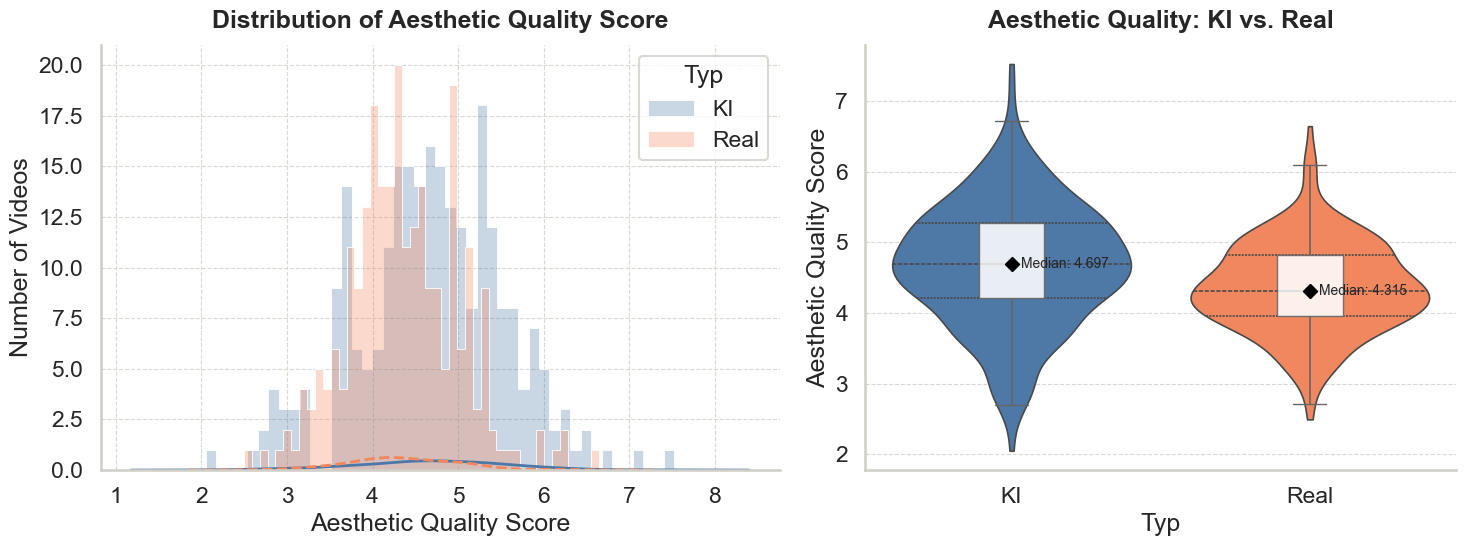

In [10]:
# Visualisierung der ästhetischen Qualität
sns.set_theme(
    style='whitegrid',
    context='talk',
    rc={
        'axes.facecolor': 'white',
        'figure.facecolor': 'white',
        'grid.color': '#d9d9d2',
        'grid.linestyle': '--',
        'grid.linewidth': 0.8,
        'axes.edgecolor': '#d0d0c8',
    },
)

PALETTE_COLOR = {'KI': '#4C78A8', 'Real': '#F5855B'}
ORDER = ['KI', 'Real']

plot_label_map = {
    'aesthetic_quality_score': 'Ästhetischer Qualitätswert',
    'aesthetic_quality_scored_frames': 'Ausgewertete Frames für die Ästhetikbewertung',
}

plot_note_map = {
    'aesthetic_quality_score': 'Höhere Werte deuten auf eine höhere modellbasierte visuelle Qualität hin.',
    'aesthetic_quality_scored_frames': 'Mehr ausgewertete Frames bedeuten, dass mehr Videoframes in die Ästhetikbewertung eingingen.',
}

value_fmt = {
    'aesthetic_quality_score': '{:.2f}',
    'aesthetic_quality_scored_frames': '{:.0f}',
}

metrics = ['aesthetic_quality_score', 'aesthetic_quality_scored_frames']

df_plot = df.copy()
df_plot['typ'] = df_plot['influencer_type'].map({'ai': 'KI', 'real': 'Real'}).fillna(df_plot['influencer_type'])

fig, axes = plt.subplots(2, 2, figsize=(15.2, 10.2), gridspec_kw={'width_ratios': [1.0, 1.2]})

for row_idx, metric in enumerate(metrics):
    metric_df = df_plot[['typ', metric]].dropna().copy()
    if metric_df.empty:
        continue

    display_df = metric_df.copy()
    if len(display_df) >= 10:
        lower = display_df[metric].quantile(0.01)
        upper = display_df[metric].quantile(0.95)
        display_df = display_df[display_df[metric].between(lower, upper)]

    summary = (
        metric_df.groupby('typ')[metric]
        .agg(q1=lambda x: x.quantile(0.25), median='median', q3=lambda x: x.quantile(0.75), mean='mean', n='count')
        .reindex(ORDER)
    )

    ax_left = axes[row_idx, 0]
    x_positions = np.array([0.00, 0.36])

    for pos, grp in zip(x_positions, ORDER):
        if grp not in summary.index or pd.isna(summary.loc[grp, 'median']):
            continue
        color = PALETTE_COLOR[grp]
        q1 = summary.loc[grp, 'q1']
        med = summary.loc[grp, 'median']
        q3 = summary.loc[grp, 'q3']
        mean = summary.loc[grp, 'mean']
        n_obs = int(summary.loc[grp, 'n'])

        ax_left.vlines(pos, q1, q3, color=color, linewidth=7, alpha=0.88, zorder=2)
        ax_left.scatter(pos, med, s=120, color=color, edgecolor='white', linewidth=1.2, zorder=3)
        ax_left.scatter(pos, mean, s=75, color='white', edgecolor=color, linewidth=1.8, marker='D', zorder=4)
        ax_left.text(pos + 0.03, med, f"Median {value_fmt[metric].format(med)}", va='center', ha='left', fontsize=10)
        ax_left.text(pos + 0.03, mean, f"Mittel {value_fmt[metric].format(mean)}", va='center', ha='left', fontsize=9, color='#5a5a55')
        ax_left.text(pos, q1, f"n={n_obs}", va='top', ha='center', fontsize=9, color='#5a5a55')

    ax_left.set_xlim(-0.12, 0.68)
    ax_left.set_xticks(x_positions)
    ax_left.set_xticklabels(ORDER)
    ax_left.set_ylabel(plot_label_map[metric])
    ax_left.set_xlabel('Typ')
    ax_left.set_title(f"Typischer Wert und Streuung: {plot_label_map[metric]}", pad=12, weight='semibold')
    ax_left.text(
        0.02,
        0.04,
        'Farbpunkt = Median | weisse Raute = Mittelwert | Balken = mittlere 50 %',
        transform=ax_left.transAxes,
        ha='left',
        va='bottom',
        fontsize=9.5,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#d0d0c8', alpha=0.96),
    )
    ax_left.text(
        0.02,
        0.96,
        plot_note_map[metric],
        transform=ax_left.transAxes,
        ha='left',
        va='top',
        fontsize=10,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#d0d0c8', alpha=0.96),
    )

    ax_right = axes[row_idx, 1]
    sns.violinplot(
        data=display_df,
        x='typ',
        y=metric,
        order=ORDER,
        hue='typ',
        dodge=False,
        palette=PALETTE_COLOR,
        inner=None,
        cut=0,
        linewidth=1.2,
        saturation=0.95,
        legend=False,
        ax=ax_right,
    )
    sns.boxplot(
        data=display_df,
        x='typ',
        y=metric,
        order=ORDER,
        width=0.22,
        fliersize=0,
        boxprops={'facecolor': 'white', 'alpha': 0.88, 'zorder': 3},
        whiskerprops={'linewidth': 1.2},
        capprops={'linewidth': 1.2},
        medianprops={'color': 'black', 'linewidth': 1.7},
        ax=ax_right,
    )

    medians = display_df.groupby('typ')[metric].median().reindex(ORDER)
    for x_pos, grp in zip(range(len(ORDER)), ORDER):
        med_val = medians.get(grp)
        if pd.isna(med_val):
            continue
        ax_right.scatter(x_pos, med_val, c='black', s=42, zorder=5)
        ax_right.text(x_pos + 0.05, med_val, f"Median {value_fmt[metric].format(med_val)}", va='center', fontsize=10)

    ax_right.set_title(f"Verteilung innerhalb der Gruppen: {plot_label_map[metric]}", pad=12, weight='semibold')
    ax_right.set_xlabel('Typ')
    ax_right.set_ylabel(plot_label_map[metric])
    ax_right.text(
        0.02,
        0.96,
        'Sehr hohe Werte sind nur für die Darstellung ausgeblendet\n(1. bis 95. Perzentil).',
        transform=ax_right.transAxes,
        ha='left',
        va='top',
        fontsize=9.5,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#d0d0c8', alpha=0.96),
    )

for ax in np.ravel(axes):
    sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()
plt.show()



In [11]:
def cohens_d(x, y):
    x, y = np.asarray(x), np.asarray(y)
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    dof = nx + ny - 2
    pooled = np.sqrt(((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / dof)
    if pooled == 0 or np.isnan(pooled):
        return np.nan
    return (np.mean(x) - np.mean(y)) / pooled

results = []
ai_vals = df.loc[df['influencer_type'] == 'ai', 'aesthetic_quality_score'].dropna()
real_vals = df.loc[df['influencer_type'] == 'real', 'aesthetic_quality_score'].dropna()
if len(ai_vals) > 0 and len(real_vals) > 0:
    t_stat, t_p = ttest_ind(ai_vals, real_vals, equal_var=False, nan_policy='omit')
    d = cohens_d(ai_vals, real_vals)
    results.append({
        'metric': 'aesthetic_quality_score',
        'test': 't-test',
        'n_ai': len(ai_vals),
        'n_real': len(real_vals),
        'mean_ai': ai_vals.mean(),
        'mean_real': real_vals.mean(),
        'cohens_d': d,
        't_stat': t_stat,
        'p_value': t_p,
    })
results_df = pd.DataFrame(results).round(4)
display(results_df)


,metric,test,n_ai,n_real,mean_ai,mean_real,cohens_d,t_stat,p_value
0,aesthetic_quality_score,t-test,250,250,4.6839,4.3634,0.4155,4.6459,0.0


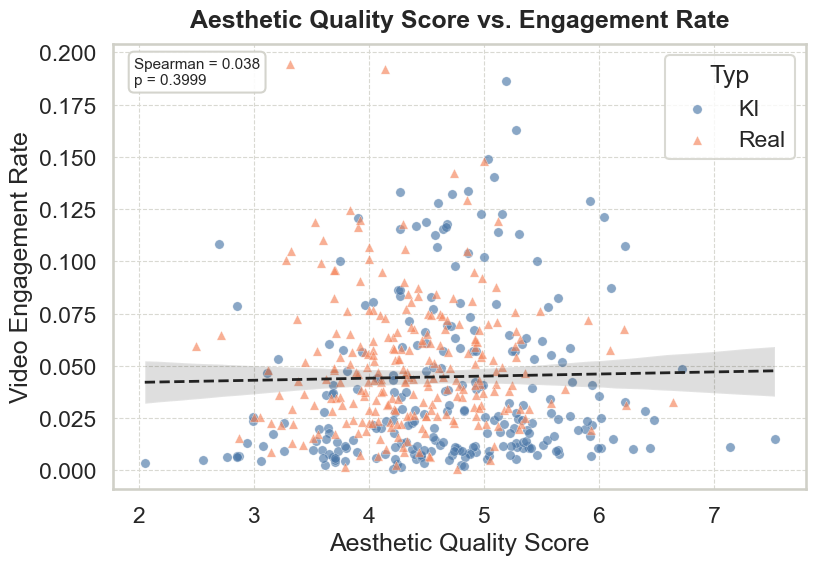

,Metrik,Spearman_rho,p_Wert
0,Aesthetic Quality Score,0.0377,0.3999


In [12]:
# Zusammenhang zwischen ästhetischer Qualität und Engagement-Rate
sns.set_theme(
    style='whitegrid',
    context='talk',
    rc={
        'axes.facecolor': 'white',
        'figure.facecolor': 'white',
        'grid.color': '#d9d9d2',
        'grid.linestyle': '--',
        'grid.linewidth': 0.8,
        'axes.edgecolor': '#d0d0c8',
    },
)

PALETTE_COLOR = {'KI': '#4C78A8', 'Real': '#F5855B'}
MARKER = {'KI': 'o', 'Real': '^'}
LINESTYLE = {'KI': '-', 'Real': '--'}

df_plot = df.copy()
df_plot['typ'] = df_plot['influencer_type'].map({'ai': 'KI', 'real': 'Real'}).fillna(df_plot['influencer_type'])

corr_results = []
if 'video_engagement_rate' in df_plot.columns:
    metric_df = df_plot[['typ', 'aesthetic_quality_score', 'video_engagement_rate']].dropna().copy()
    rho_all, p_all = spearmanr(metric_df['aesthetic_quality_score'], metric_df['video_engagement_rate'], nan_policy='omit')
    corr_results.append({'Metrik': 'aesthetic_quality_score', 'Methode': 'Spearman', 'Spearman_rho': rho_all, 'p_Wert': p_all})

    fig, ax = plt.subplots(figsize=(8.8, 6.1))
    stat_lines = []

    for grp in ['KI', 'Real']:
        sub = metric_df[metric_df['typ'] == grp].copy()
        if sub.empty:
            continue
        rho_grp, p_grp = spearmanr(sub['aesthetic_quality_score'], sub['video_engagement_rate'], nan_policy='omit')
        stat_lines.append(f"{grp}: rho={rho_grp:.2f}")
        sns.scatterplot(
            data=sub,
            x='aesthetic_quality_score',
            y='video_engagement_rate',
            color=PALETTE_COLOR[grp],
            marker=MARKER[grp],
            edgecolor='white',
            linewidth=0.35,
            s=48,
            alpha=0.58,
            ax=ax,
            label=grp,
        )
        sns.regplot(
            data=sub,
            x='aesthetic_quality_score',
            y='video_engagement_rate',
            scatter=False,
            ci=None,
            line_kws={'color': PALETTE_COLOR[grp], 'linewidth': 2.2, 'linestyle': LINESTYLE[grp]},
            ax=ax,
        )

    ax.set_title('Ästhetische Qualität und Engagement-Rate', pad=12, weight='semibold')
    ax.set_xlabel('Ästhetischer Qualitätswert')
    ax.set_ylabel('Engagement-Rate pro Video')
    ax.text(
        0.03,
        0.97,
        '\n'.join(stat_lines),
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=10.5,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#d0d0c8', alpha=0.95),
    )
    ax.text(
        0.03,
        0.06,
        'Linien zeigen den Trend innerhalb von KI bzw. Real.',
        transform=ax.transAxes,
        ha='left',
        va='bottom',
        fontsize=9.5,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#d0d0c8', alpha=0.95),
    )
    ax.legend(title='Typ', frameon=True, facecolor='white', edgecolor='#d0d0c8', loc='best')
    sns.despine(ax=ax, top=True, right=True)

    plt.tight_layout()
    plt.show()
else:
    print('video_engagement_rate column not available; skipping correlation analysis.')

corr_df = pd.DataFrame(corr_results).round(4)
display(corr_df)



In [13]:
print('Kurzinterpretation:')

def sig_label(p):
    return 'signifikant' if pd.notna(p) and p < 0.05 else 'nicht signifikant'

if 'results_df' in globals() and not results_df.empty:
    row = results_df.iloc[0]
    mean_diff = row['mean_ai'] - row['mean_real']
    direction = 'hoeher bei KI' if mean_diff > 0 else ('hoeher bei Real' if mean_diff < 0 else 'kein Unterschied')
    print(f"- Ästhetische Qualität (t-Test): {sig_label(row['p_value'])} (p={row['p_value']:.4f}). Interpretation: Höhere Werte stehen für höhere visuelle Qualität ({direction}).")

if 'corr_df' in globals() and not corr_df.empty:
    row = corr_df.iloc[0]
    rho = row['Spearman_rho']
    p = row['p_Wert']
    direction = 'positiv' if rho > 0 else ('negativ' if rho < 0 else 'neutral')
    method_label = row['Methode'] if 'Methode' in corr_df.columns else 'Spearman'
    print(f"- Engagement ~ aesthetic_quality_score ({method_label}): {sig_label(p)} (rho={rho:.3f}, p={p:.4f}). Interpretation: {direction}er Zusammenhang zwischen visueller Qualität und Engagement.")



Kurzinterpretation:
- Ästhetische Qualität (t-Test): signifikant (p=0.0000). Interpretation: Höhere Werte stehen für höhere visuelle Qualität (höher bei KI).
- Engagement ~ aesthetic_quality_score (Spearman + Regression): nicht signifikant (rho=0.038, p=0.3999). Interpretation: positiver Effekt visueller Qualität auf Engagement.
